<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
Artificial Intelligence <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
FALL 2024<br>
<font color=3C99D size=5>
Practical Assignment 4 - Neural Networks <br>
<font color=696880 size=4>
Arash Ziyaei Razban - Mahan Bayhaghi

____________

# Personal Data
Please fill in your details below to help us keep track of your submission.

Student Name: `Nasim Javdani`

Student ID: `402170013`

# Recurrent Neural Network (RNN)

Nowadays machine learning algorithms and models are used to solve too many types of problems. One of the most important problems is sequence modeling. Sequence modeling is the ability of an algorithm to model, interpret, make predictions about, or generate sequence data like audio, text, etc.

One of the most used algorithms to solve sequence modeling problems is the Recurrent Neural Network which is a specialized form of the classical Artificial Neural Network (Multi-Layer Perceptron). Below is a picture of this network architecture:

<img src="RNN.jpg" width="400" height="200">

In sequences there is a common feature, that each value has some dependency on its previous members. A simple example is arithmetic sequence: $a_i = i * d + a_0, 0 \leq i$, where $a_n$ is dependent on $a_{n-1}$. So based on this nature of the sequences, there is a loop inside the RNN cell. This helps the RNN cell to remember some information about the previous activation values.

In general, RNN is used to model sequences because of the following advantages:
+ handles variable-length dependencies.
+ Tracks dependencies.
+ Maintains information about the order.
+ Shares parameters across the sequence.


# What you are going to do in this notebook

+ `Step1.` You have to design a simple neural network that has only 4 neurons, inspired by the RNNs architecture, and use it to predict the next number of an arithmetic sequence.

+ `Step2.` You have to increase the number of the neurons to 8. Then you have create a complex dataset of arithmetic sequences, that in each with a number of `d` called $1 \leq n$.

+ `Step3.` In the previous sections, you will find out why just using the basic architecture of RNNs does not work for complex data. So, for this step, you have to implement a Gated Recurrent Unit (GRU) from scrach to train and test it over the MNIST dataset and compare it with PyTorch GRU.

# START TO LEARN ABOUT RNNs (30 points)
Step 1. First, we start with simple data, like arithmetic sequence: $a_i = i * d + a_0, 0 \leq i$.

You have to design a simple neural network (only 4 neurons) inspired from the RNNs to predict the next number in the sequence.

`Note`: First, try to solve this problem theoretically (find the final values for your network's weights) and then implement it.

`your answer`


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

In [3]:
# TODO
import random
def CustomDataset(max_length = 20, size = 10000):
    """
        Generate your dataset with following details:
        -100 <= a_i <= 100
        -20 <= d <= 20
        len(sequence) <= max_length

        Parameters:
            - max_length = 20
            - size = 10000

        Returns:
            - dataset = [(length, sequence, next_number in the sequence) for each sequence]
    """
    dataset = []

    for _ in range(size):
        a0 = random.randint(-100, 100)
        d = random.randint(-20, 20)

        length = random.randint(1, max_length)

        sequence = [a0 + i * d for i in range(length)]

        next_number = sequence[-1] + d

        dataset.append((length, sequence, next_number))

    return dataset


# Now create the model:
Based on the this task design your model.
+ Note that, your model should inspire from the behavior of RNNs.
+ Solve this problem theoretically. Then you will find out you only need 4 neurons.

In [4]:
# TODO
class Model(nn.Module):

    def __init__(self,input_size=1, hidden_size=4):
        super(Model,  self).__init__()
        self.hidden_size = hidden_size
        self.rnn_cell = nn.RNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):

        h = self.rnn_cell(x, h)
        y = self.fc(h)
        return y, h

dataset = CustomDataset(max_length=20, size=10)
model = Model()



# Training Loop
Now you have to train your model.

Note, your architecture must be based on RNNs. This means that you have to set a hidden state called `h` and use it to create a loop for your model like RNNs.

In [5]:
dataset = CustomDataset(max_length=20, size=1000)

model = Model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for length, x, y in dataset:
        optimizer.zero_grad()

        x_tensor = torch.tensor(x, dtype=torch.float32).view(-1, 1)
        y_tensor = torch.tensor(y, dtype=torch.float32).view(1)

        h = torch.zeros(1, model.hidden_size)

        for i in range(length):
            out, h = model(x_tensor[i].view(1, -1), h)

        loss = criterion(out, y_tensor)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/10, Loss: 25274596.0221
Epoch 2/10, Loss: 24506296.6578
Epoch 3/10, Loss: 23780625.4116
Epoch 4/10, Loss: 23081336.5621
Epoch 5/10, Loss: 22406541.2752
Epoch 6/10, Loss: 21754941.1558
Epoch 7/10, Loss: 21125388.3843
Epoch 8/10, Loss: 20516919.8346
Epoch 9/10, Loss: 19928729.8403
Epoch 10/10, Loss: 19359999.2775


# Weights Evaluation
Print the weights of the model.

You can see, model's weight are exactly same as what you have found in theoretical way.

In [ ]:
print("Model's weights:")
print(model.state_dict())


Model's weights:
OrderedDict([('rnn_cell.weight_ih', tensor([[-0.0879],
        [ 0.2011],
        [ 0.3918],
        [-0.1232]])), ('rnn_cell.weight_hh', tensor([[ 0.4675, -0.4219, -0.2272,  0.0961],
        [ 0.0258, -0.2842, -0.3406,  0.3911],
        [-0.3837, -0.0869, -0.0608, -0.1868],
        [ 0.1363,  0.0284, -0.2561,  0.2307]])), ('rnn_cell.bias_ih', tensor([ 0.4522,  0.4010, -0.3920, -0.2577])), ('rnn_cell.bias_hh', tensor([ 0.1194,  0.1954, -0.4206, -0.2960])), ('fc.weight', tensor([[-0.3703, -0.4561, -0.0588,  0.3514]])), ('fc.bias', tensor([-0.3615]))])


# Write your opinion
How this model use hidden state? Why hidden state is helpful?

The hidden state retains information about previous sequence elements, enabling the model to capture dependencies and context across time steps. It acts as memory, ensuring the model considers the entire sequence for accurate predictions.








# Analysis of long-term dependencies (40 points)
Step 2. Now, we are going to do some analysis. In the previous, both the dataset and model were simple. Now, we want to make it a little complex.

+ Assume the lengths for all sequences are equal.
+ Consider each sequence has `n` number of `d`:
    - e.g, $a_0, a_0 + d_0, a_1 + d_1, a_2 + d_2, ...., a_{n-1} + d_{n-1}, a_{n} + d_0, a_{n+1} + d_1, ...$
+ Change your model: just increase the number of neurons to 8. Also, because your input's dimension has changed, you have to increase the hidden state `h` dimension.
+ Create a loop over all possible $2 \leq n \leq 10$ and generate a dataset for each one. Then train a new model for each dataset.
+ At the end, show a `TotalLoss - numberOfd` plot.

In [6]:
# new model
# TODO
class Model(nn.Module):
    """
        Design your model.
    """
    def __init__(self, input_dim, hidden_dim=8):
        super(Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
# TODO
def CustomDataset(n, length = 20, size = 10000):
    """
        Generate your dataset with following details:
        -100 <= a_i <= 100
        -20 <= d <= 20

        Parameters:
            - n: number of d in sequences
            - length = 20 (length of all sequences)
            - size = 10000

        Returns:
            - dataset = [(length, sequence, next_number in the sequence) for each sequence]
    """
    dataset = []
    for _ in range(size):
        a0 = torch.randint(-100, 101, (1,))  # Random initial value a0
        d = torch.randint(-20, 21, (n,))    # Random d values for the sequence
        sequence = [a0 + sum(d[:i]) for i in range(length)]  # Generate the sequence
        dataset.append((length, sequence, sequence[-1] + d[0]))  # Include next number prediction

    return dataset

In [8]:
losses = []
epochs = 10

for n in range(2, 10):
    total_loss = 0
    dataset = CustomDataset(n=n)

    model = Model(input_dim=20)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    for epoch in range(epochs):
        epoch_loss = 0
        for _, (length, sequence, target) in enumerate(dataset):
            sequence_tensor = torch.tensor(sequence, dtype=torch.float32).view(1, -1)
            target_tensor = torch.tensor(target, dtype=torch.float32).view(1, -1)

            optimizer.zero_grad()
            output = model(sequence_tensor)
            loss = criterion(output, target_tensor)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        scheduler.step()
        total_loss += epoch_loss / len(dataset)

    losses.append(total_loss / epochs)

for loss in losses:
    print(loss)


<ipython-input-8-93e6d2b10105>:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_tensor = torch.tensor(target, dtype=torch.float32).view(1, -1)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


13.374965206405705
14.289587435786913
15.321647847554027
16.534262095707
19.29898553845071
17.549569009186353
18.978757563453957
21.16456233620203


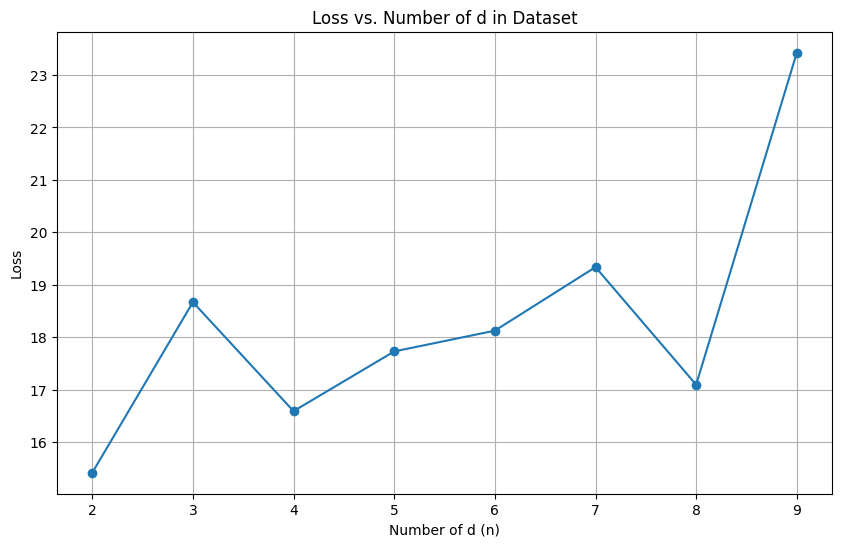

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), losses, marker='o')
plt.title('Loss vs. Number of d in Dataset')
plt.xlabel('Number of d (n)')
plt.ylabel('Loss')
plt.grid()
plt.show()

# Write your opinion

+ You can see, as the number of d in the sequences increases the amount of the total loss increases too. Why?


As the number of d increases, the model must learn more complex relationships and dependencies between sequence elements. This complexity increases the error due to the gradient vanishing problem during backpropagation.

+ Can you mathematically explain your opinion? (help: There are some gradient issues!)


In RNNs, gradients are propagated through time using repeated matrix multiplications. If the weights in these matrices are small, gradients diminish exponentially (
gradient
∼
𝑊**𝑡
 ). This makes it difficult to update weights effectively for long sequences, leading to poor learning and higher loss.

+ Can you explain the problem of Long-term dependencies in RNNs?


Long-term dependencies occur when information from earlier in the sequence is needed for predictions much later. RNNs struggle with this due to vanishing gradients, making it challenging to retain or propagate useful information over many time steps. This results in ineffective learning of distant dependencies.

# Gated Recurrent Units (GRUs) (30 points)

Step3. In the previous section, you saw, simple recurrent models cannot remember information from the past. This is a big problem because in real-world applications sequences have a lot of dependencies on their past time steps and we have to find a way to remember the information from the past. To address this problem, researchers have designed other architecture that can selectively remember or forget information over time. Like: `Long-Short Term Memory (LSTM)` and `Gated Recurrent Unit (GRU)`. The key building block behind these architectures is `gate`.

#### GATE:
These networks, use gates to track information throughout many time steps:
+ Add information, when the information is needed.
+ Remover information, When information is not important

<img src="GATE.jpg" width="400" height="200">

#### Long-Short Term Memory:
LSTM is an improved version of RNNs. In a classical recurrent model, there is a single hidden state `h` which is used to help the model to remember some information over time. But this is not enough to learn long-term dependencies. Using gates, LSTM is capable of addressing the problem of long-term dependencies.

LSTM cell:

<img src="LSTM.jpg" width="400" height="200">

GATES:
+ <font color=green size=3> Forget gate:</font> To forget irrelevant information.
+ <font color=red size=3> Store gate:</font> Decide what part of new is relevant.
+ <font color=orange size=3> Update:</font> update cell state values.
+ <font color=blue size=3> Output gate:</font> Controls what information is sent to the next time step.

This architecture addresses the gradient issues you have described in the previous section. (How?)

Forget Gate: Removes irrelevant information, avoiding unnecessary gradient accumulation.


Input Gate: Adds only relevant new information to the cell state.
Cell State: Preserves long-term information with minimal changes, reducing gradient vanishing.


Output Gate: Regulates what information flows to the next time step.

#### Gated Recurrent Unit (GRU):
Like LSTM, GRU is designed to model sequential data by allowing information to be selectively remembered or forgotten over time.

GRU cell:

<img src="GRU.jpg" width="400" height="200">

GATES and other parts:
+ <font color=green size=3> Reset gate:</font> How much of previous hidden state to forget.
    - $r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$
+ <font color=orange size=3> Update gate:</font> How much of the candidate activation vector to incorporate into the new hidden state.
    - $z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$
    
+ <font color=red size=3> Candidate Activation vector:</font> Computed using the current input x and modified version of the previous hidden state that is `reset` by the reset gate.
    - $\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t])$

+ <font color=blue size=3> Hidden state</font>
    - $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$

Note: the $W_r$, $W_z$, $W_h$ are the weights associated with the GRU cell.

# GRU Implementation
Now, implement a Gated Recurrent Unit from scratch.

In [37]:
class GRU_cell(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_calsses):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_calsses

        self.reset_gate = nn.Linear(self.input_dim + self.hidden_dim, self.hidden_dim)
        self.update_gate = nn.Linear(self.input_dim + self.hidden_dim, self.hidden_dim)
        self.candidate = nn.Linear(self.input_dim + self.hidden_dim, self.hidden_dim)

        self.output = nn.Linear(self.hidden_dim, self.num_classes)
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()


    def forward(self, x, h_prev):
        combined = torch.cat((x, h_prev), dim=1)
        r_t = self.sigmoid(self.reset_gate(combined))
        z_t = self.sigmoid(self.update_gate(combined))
        combined_reset = torch.cat((r_t * h_prev, x), dim=1)
        h_tilde = self.tanh(self.candidate(combined_reset))
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        output = self.output(h_t)
        return h_t, output

# MNIST
MNIST database is a collection of handwritten digits. You are going to use this database to train and test your GRU cell.

First, to download this database run the cell below.

In [11]:
database = MNIST(root = 'data/', download = True)
# TODO
# get train and test data - use transforms.ToTensor() to convert images to tensor
train_data = MNIST(root='data/', train=True, transform=transforms.ToTensor(), download=True)
test_data = MNIST(root='data/', train=False, transform=transforms.ToTensor(), download=True)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.25MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



Show the image and label of one instance from the train data.

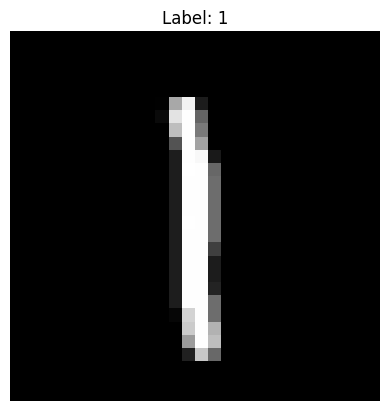

In [25]:
import matplotlib.pyplot as plt

# Get one instance of the train data
image, label = train_data[14]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [26]:
image, label = train_data[0]
print("Image Tensor:", image)

Image Tensor: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0

### Write a generate custom dataset function
+ For each data in the database convert, use one-hot encoding from pytorch to encode your label to a vector. This is necessary for computing the amount of loss.
+ It is common to use batches of data to train our model simultaneously on a batch. The length of a batch at most is `BATCH_SIZE`.
    - Note: you can also train your model on each data (one by one) but the training part will take too much time.
+ Return batches of data.

In [28]:
HIDDEN_DIM = 15
INPUT_DIM = 28
NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 30

In [33]:
def CustomDataset(data, batch_size = BATCH_SIZE):
    """
        Generate batches of data. Use one-hot encoding to encode your labels according to number of classes.

        Parameters:
            - data: MNIST database
            - batch_size = BATCH_SIZE

        Returns:
            - batches = A list of [(image_tensor, encoded label)]. Each batch's length is at most BATCH_SIZE
    """
    NUM_CLASSES = 10
    batches = []
    batch_images = []
    batch_labels = []

    for image_tensor, label in data:
        encoded_label = torch.zeros(NUM_CLASSES)
        encoded_label[label] = 1.0

        batch_images.append(image_tensor)
        batch_labels.append(encoded_label)

        if len(batch_images) == batch_size:
            batches.append((torch.stack(batch_images), torch.stack(batch_labels)))
            batch_images = []
            batch_labels = []

    if batch_images:
        batches.append((torch.stack(batch_images), torch.stack(batch_labels)))

    return batches

### Training loop
write your training loop.
+ For loss function: use `CrossEntropyLoss` function
+ Use adam optimizer
+ To optimize your training process, you can use `optim.lr_schduler`. (Why this will improve the training process?)
    - `your answer`
+ Note: Also, in each time step give one row of image tensor to the model because your model is sequential (you also can use each column).

In [41]:
# TODO
# create batches
batches = CustomDataset(train_data)

# Initialize model, loss function, and optimizer
model = GRU_cell(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


# use scheduler to set learning rate

# training loop
# TODO
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x_batch, y_batch in batches:
        batch_loss = 0
        h_t = torch.zeros(x_batch.size(0), HIDDEN_DIM)

        for t in range(x_batch.size(2)):
            x_t = x_batch[:, :, t].squeeze(1)
            h_t, output = model(x_t, h_t)

        loss = criterion(output, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_loss += loss.item()

    scheduler.step()
    total_loss += batch_loss
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(batches)}")



Epoch 1/30, Loss: 0.0022898175314799555
Epoch 2/30, Loss: 0.0016683460806986925
Epoch 3/30, Loss: 0.00132638406651869
Epoch 4/30, Loss: 0.0011695676775120977
Epoch 5/30, Loss: 0.0011080804664188866
Epoch 6/30, Loss: 0.0010531560571463124
Epoch 7/30, Loss: 0.0009748261493406316
Epoch 8/30, Loss: 0.0008895444844577358
Epoch 9/30, Loss: 0.000828636417002566
Epoch 10/30, Loss: 0.000779851413230652
Epoch 11/30, Loss: 0.000782586046373412
Epoch 12/30, Loss: 0.000756888692058734
Epoch 13/30, Loss: 0.0007308187769420111
Epoch 14/30, Loss: 0.000703956081923137
Epoch 15/30, Loss: 0.0006761224285117599
Epoch 16/30, Loss: 0.0006480649717326866
Epoch 17/30, Loss: 0.0006206357784108566
Epoch 18/30, Loss: 0.0005943653171758916
Epoch 19/30, Loss: 0.0005690517710216009
Epoch 20/30, Loss: 0.00054379649507974
Epoch 21/30, Loss: 0.0005102049567297832
Epoch 22/30, Loss: 0.0004976082013359965
Epoch 23/30, Loss: 0.0004873479416629653
Epoch 24/30, Loss: 0.00047803157046913847
Epoch 25/30, Loss: 0.000469415172

### Test your model on Test data
Use the test data to evaluate your model.
+ Print the accuracy of your model (should be greater than $94\%$).
+ Show some predictions with actual value from the test data.

In [42]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    test_batches = CustomDataset(test_data, batch_size=BATCH_SIZE)

    for x_batch, y_batch in test_batches:
        h_t = torch.zeros(x_batch.size(0), HIDDEN_DIM)

        for t in range(x_batch.size(2)):
            x_t = x_batch[:, :, t].squeeze(1)
            h_t, output = model(x_t, h_t)

        predictions = torch.argmax(output, dim=1)
        labels = torch.argmax(y_batch, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = (correct / total) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 94.65%


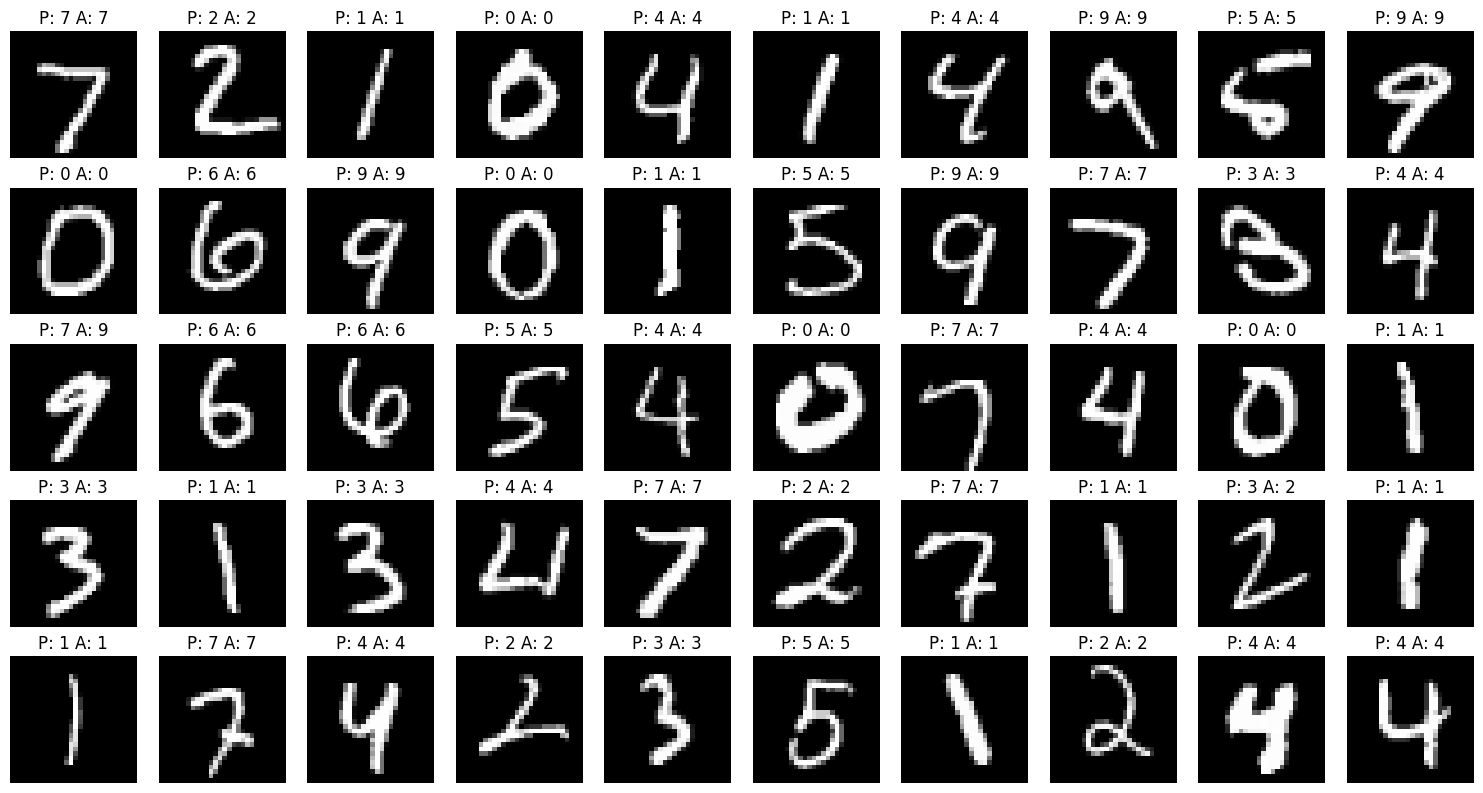

In [43]:
with torch.no_grad():
    displayed = 0
    fig, axes = plt.subplots(5, 10, figsize=(15, 8))
    axes = axes.flatten()

    for x_batch, y_batch in test_batches:
        h_t = torch.zeros(x_batch.size(0), HIDDEN_DIM)

        for t in range(x_batch.size(2)):
            x_t = x_batch[:, :, t].squeeze(1)
            h_t, output = model(x_t, h_t)

        predictions = torch.argmax(output, dim=1)
        labels = torch.argmax(y_batch, dim=1)

        for i in range(x_batch.size(0)):
            if displayed >= 50:
                break

            image = x_batch[i].squeeze().cpu().numpy()
            axes[displayed].imshow(image, cmap='gray')
            axes[displayed].set_title(f"P: {predictions[i].item()} A: {labels[i].item()}")
            axes[displayed].axis('off')
            displayed += 1

        if displayed >= 50:
            break

    plt.tight_layout()
    plt.show()
